In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
x = np.array([1,2,3,5,6,7,8,9]).reshape(-1,1)
y = np.array([3,1,4,6,5,8,7,8]).reshape(-1,1)

In [5]:
X = np.column_stack((np.ones_like(x),x))

In [9]:
b = np.linalg.inv(X.T@X) @ X.T @ y #对应空间标量投影
b

array([[1.26751592],
       [0.77707006]])

In [11]:
X.T@X

array([[  8,  41],
       [ 41, 269]])

In [13]:
np.linalg.inv(X.T@X)

array([[ 0.57112527, -0.08704883],
       [-0.08704883,  0.01698514]])

In [15]:
x_array = np.linspace(0,10)
X_array = np.column_stack((np.ones_like(x_array),x_array))

y_array_pred = X_array @ b #用求出来的b计算直线上其它点的预测值 用于画直线
y_pred = X@b

In [17]:
error = y-y_pred
error

array([[ 0.95541401],
       [-1.82165605],
       [ 0.40127389],
       [ 0.84713376],
       [-0.92993631],
       [ 1.29299363],
       [-0.48407643],
       [-0.2611465 ]])

In [19]:
error.T@error

array([[7.94904459]])

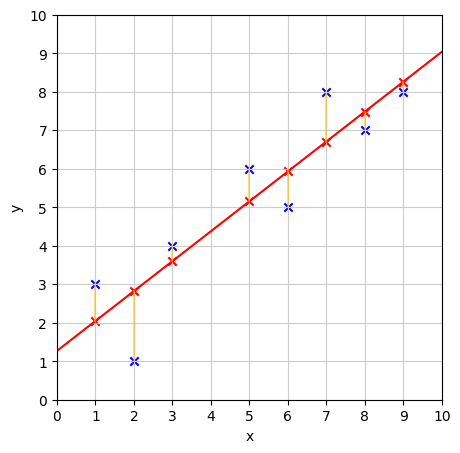

In [37]:
fig,ax = plt.subplots(figsize = (5,5))

ax.scatter(x,y,marker = 'x',color = 'b')
ax.plot(x_array,y_array_pred,color = 'r')
ax.scatter(x,y_pred,marker = 'x',color = 'r')
#这里的for中添加的[]就表示这是专门的列表到循环
    #将for前面的语句计算出来的值append到列表中.本质是for和append组合的语法糖
#plot中的参数((x1,x2),(y1,y2))是索引一一对应绘制每一条直线
ax.plot(([i for i in x.squeeze()],[i for i in x.squeeze()]),
        ([j for j in y_pred.squeeze()],[j for j in y.squeeze()]),
        c = '#FFC000',alpha = 0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0,10)
ax.set_ylim(0,10)
#arange(11)生成[0,10]的整数
ax.set_xticks(np.arange(11))
ax.set_yticks(np.arange(11))
ax.grid(True,c = '0.8')
ax.set_aspect('equal','box')

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [42]:
x = np.array([1,2,3,5,6,7,8,9]).reshape(-1,1)
y = np.array([3,1,4,6,5,8,7,8]).reshape(-1,1)

In [44]:
model = LinearRegression()
model.fit(x,y)

LinearRegression()

In [52]:
b1 = model.coef_
b0 = model.intercept_

#按照行方向堆叠,与np.row_stack完全等价  官网推荐用vstack因为-vertical(垂直)
print('参数向量 b = ',np.vstack([b0,b1]))

参数向量 b =  [[1.26751592]
 [0.77707006]]


In [54]:
y_pred = model.predict(x)

In [56]:
x_array = np.linspace(0,10).reshape(-1,1)
y_array_gred = model.predict(x_array)

In [58]:
error = y - y_pred

In [60]:
squared_L2_norm = error.T@error
print('误差平方和 = ',squared_L2_norm)

误差平方和 =  [[7.94904459]]


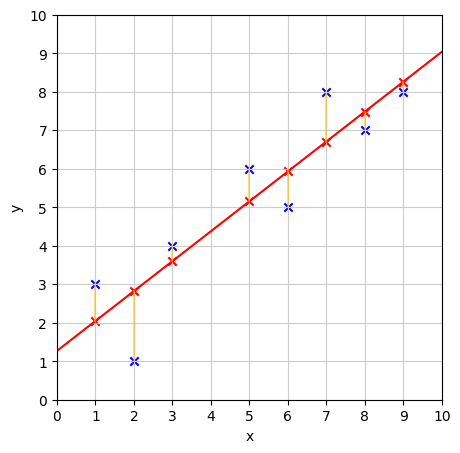

In [68]:
fig,ax = plt.subplots(figsize = (5,5))

ax.scatter(x,y,marker = 'x',color = 'b')

ax.plot(x_array,y_array_pred,color = 'r')

ax.scatter(x,y_pred,marker = 'x',color='r')

#.squeeze是将二维数组转化为一维方便计算(n,1)的1被删除变成1D
    #本质是删除某些长度为1的维度.进行降维
    #用参数axis =? 压缩特定维度
ax.plot(([i for i in x.squeeze()],[i for i in x.squeeze()]),
        ([j for j in y_pred.squeeze()],[j for j in y.squeeze()]),
        c = '#FFC000',alpha = 0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_xticks(np.arange(11))
ax.set_yticks(np.arange(11))
ax.grid(True,c = '0.8')
#'box'表示调整绘图区的边框(不是数据)
    #这里的意思是调整边框不改变范围
        #另一种是调整边框改变范围(范围显示比例不变,范围变广了)
ax.set_aspect('equal','box')

In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [73]:
x = np.array([1,2,3,5,6,7,8,9]).reshape(-1,1)
y = np.array([3,1,4,6,5,8,7,8]).reshape(-1,1)

In [75]:
X = x

In [77]:
b = np.linalg.inv(X.T@X) @ X.T @ y
b

array([[0.97026022]])

In [79]:
X.T@X

array([[269]])

In [81]:
np.linalg.inv(X.T@X)

array([[0.00371747]])

In [83]:
X.T@y

array([[261]])

In [85]:
#默认生成50个点 第三个参数是点数
x_array = np.linspace(0,10).reshape(-1,1)
X_array = x_array

y_array_pred = X_array @ b
y_pred = X@b

In [87]:
error = y - y_pred
error

array([[ 2.02973978],
       [-0.94052045],
       [ 1.08921933],
       [ 1.14869888],
       [-0.82156134],
       [ 1.20817844],
       [-0.76208178],
       [-0.73234201]])

In [89]:
error.T@error

array([[10.76208178]])

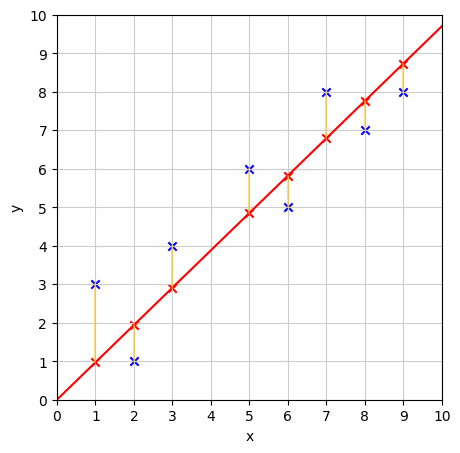

In [97]:
fig,ax = plt.subplots(figsize = (5,5))

ax.scatter(x,y,marker = 'x',color = 'b')
ax.plot(x_array,y_array_pred,color = 'r')
ax.scatter(x,y_pred,marker = 'x',color = 'r')
ax.plot(([i for i in x.squeeze()],[i for i in x.squeeze()]),
        ([j for j in y_pred.squeeze()],[j for j in y.squeeze()]),
        c = '#FFC000',alpha = 0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0,10)
ax.set_ylim(0,10)
#从0开始的整数序列 第三个参数是步长
ax.set_xticks(np.arange(11))
ax.set_yticks(np.arange(11))
ax.grid(True,c = '0.8')
ax.set_aspect('equal','box')